Case study 
group # 1

In [25]:
# install all the depensencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [26]:
#load the data
file_path = r"C:\Users\akbar\Documents\MAYERFIELD\UKDA-6970-stata\BSE_2010.dta"

# Keep numeric codes: some Stata labels are duplicated.
data = pd.read_stata(file_path, convert_categoricals=False)

df_main = pd.DataFrame(data)

df_main.head(10)

,Unqid,Country,zgor,zq88,zq89,zq90,zq91_1,zq91_2,zq101,eq1,...,CitizenadjBA,CitizenadjIn,CitizenadjPa,CitizenadjBang,Citizenadjtotal,Popdensity,Intno,Inteth,Intsex,PSUIdentifier
0,100011,1,7,1,31,1,9,4.0,8,10.0,...,138.16,304.94,359.52,74.16,919.58,5828.000000,69073,4,1,1148
1,100013,1,3,2,49,6,1,NaN,3,NaN,...,34.54,26.07,212.52,3.09,295.48,4977.419355,62138,7,1,1149
2,100014,1,3,2,33,1,4,2.0,8,10.0,...,34.54,26.07,212.52,3.09,295.48,4977.419355,62138,7,1,1149
3,100015,1,3,2,37,1,2,0.0,8,10.0,...,34.54,26.07,212.52,3.09,295.48,4977.419355,62138,7,1,1149
4,100020,1,7,1,45,1,6,2.0,8,10.0,...,138.16,304.94,359.52,74.16,919.58,5828.000000,69073,4,1,1148
5,100035,1,7,1,62,1,2,0.0,8,11.0,...,138.16,304.94,359.52,74.16,919.58,5828.000000,69073,4,1,1148
6,100037,1,4,2,27,6,4,1.0,8,NaN,...,17.27,21.33,68.88,20.60,165.53,4558.823529,70619,5,2,1443
7,100038,1,7,2,28,1,6,4.0,8,10.0,...,171.13,32.39,108.36,22.66,588.13,7715.789474,71417,6,2,1197
8,100046,1,7,2,51,6,1,NaN,11,NaN,...,259.05,10.27,0.00,8.24,593.21,7269.565217,69192,7,2,1103
9,100049,1,5,2,44,1,5,3.0,12,14.0,...,17.27,9.48,7.56,0.00,99.58,6151.851852,71570,7,2,1362


In [27]:

df_main.columns
columns = [
    "Unqid",
    "zqinc",
    "bq9_1",
    "bq9_2",
    "bq9_3",
    "ScreenEthQairre",
    "Weight_trimmedF2FALL5",
    "PSUIdentifier",
    "FinalStratum",
]

df_study = df_main[columns].copy()

display(df_study.head())
print(df_study.shape)

,Unqid,zqinc,bq9_1,bq9_2,bq9_3,ScreenEthQairre,Weight_trimmedF2FALL5,PSUIdentifier,FinalStratum
0,100011,13,2,NaN,NaN,4,1.603379,1148,90
1,100013,4,2,NaN,NaN,1,0.320863,1149,33
2,100014,4,1,2.0,NaN,4,0.738677,1149,33
3,100015,4,2,NaN,NaN,4,0.906278,1149,33
4,100020,3,2,NaN,NaN,4,2.382369,1148,90


(2787, 9)


In [28]:
# Readable names for the study columns; keep df_main unchanged.
column_names = {
    'zq91_1': 'N_in_household',
    'bq9_1': 'Party_identification',
    'zqinc': 'Household_income',
    'ScreenEthQairre':'Ethnic_group',
    'Weight_trimmedF2FALL5': 'Survey_weight'
}


In [29]:
# Keep numeric codes separately for analysis and repeatable labeling.
df_study_codes = df_main[
    ['Unqid', 'zq91_1', 'bq9_1', 'zqinc', 'ScreenEthQairre', 'Weight_trimmedF2FALL5']
].rename(columns=column_names).copy()

df_study = df_study_codes.copy()
display(df_study.head())


,Unqid,N_in_household,Party_identification,Household_income,Ethnic_group,Survey_weight
0,100011,9,2,13,4,1.603379
1,100013,1,2,4,1,0.320863
2,100014,4,1,4,4,0.738677
3,100015,2,2,4,4,0.906278
4,100020,6,2,3,4,2.382369


In [30]:
# Convert response codes to readable labels, starting from numeric data each time.
df_study = df_study_codes.copy() 
zqinc_labels = {
    -2: "Refused",
    -1: "Don't Know",
     1: "0 - 5000",
     2: "5001 - 10000",
     3: "10001 - 15000",
     4: "15001 - 20000",
     5: "20001 - 25000",
     6: "25001 - 30000",
     7: "30001 - 35000",
     8: "35001 - 40000",
     9: "41000 - 45000",
    10: "45001 - 50000",
    11: "50001 - 60000",
    12: "60001 - 70000",
    13: "70001 - 80000",
    14: "80001 or more",
    17: "Not Stated"

}

df_study['Household_income'] = df_study['Household_income'].map(zqinc_labels)

bq9_1_labels = {
    -2: "Refused",
    -1: "Don't Know",
     1: "None/No",
     2: "Labour",
     3: "Conservatives",
     4: "Liberal Democrats",
     5: "Scottish National Party (SNP)",
     6: "Plaid Cymru",
     7: "Green Party",
     8: "United Kingdom Independence Party (UKIP)",
     9: "British National Party (BNP)",
    10: "Coalition party/Conservative-Lib dem party",
    11: "Other",
    12: "Respect",
    15: "Not Stated"
}

df_study['Party_identification'] = df_study['Party_identification'].map(bq9_1_labels)

ScreenEthQairre_labels = {
    1: "Black Caribbean",
    2: "Black African",
    3: "Indian",
    4: "Pakistani",
    5: "Bangladeshi",
}

df_study['Ethnic_group'] = df_study['Ethnic_group'].map(ScreenEthQairre_labels)

# Check that every observed code has a label.
for column in ['Household_income', 'Party_identification', 'Ethnic_group']:
    unmapped = df_study_codes[column].notna() & df_study[column].isna()
    assert not unmapped.any(), f"Unmapped codes in {column}"

display(df_study.head(10))

,Unqid,N_in_household,Party_identification,Household_income,Ethnic_group,Survey_weight
0,100011,9,Labour,70001 - 80000,Pakistani,1.603379
1,100013,1,Labour,15001 - 20000,Black Caribbean,0.320863
2,100014,4,None/No,15001 - 20000,Pakistani,0.738677
3,100015,2,Labour,15001 - 20000,Pakistani,0.906278
4,100020,6,Labour,10001 - 15000,Pakistani,2.382369
5,100035,2,Conservatives,30001 - 35000,Pakistani,0.976432
6,100037,4,Labour,15001 - 20000,Pakistani,2.001654
7,100038,6,Labour,Refused,Pakistani,0.545314
8,100046,1,Labour,Refused,Black Caribbean,0.301202
9,100049,5,None/No,30001 - 35000,Black African,0.702906


In [31]:
# Export AFTER applying labels. UTF-8 with BOM also opens well in Excel.
from pathlib import Path

csv_path = Path(file_path).parent.parent / 'df_study.csv'
df_study.to_csv(csv_path, index=False, encoding='utf-8-sig')

# Read the saved CSV back to verify its labels.
study_csv = pd.read_csv(csv_path)
assert study_csv['Household_income'].equals(df_study['Household_income'])
assert study_csv['Party_identification'].equals(df_study['Party_identification'])
print(f"Saved {len(study_csv):,} rows to: {csv_path}")
display(study_csv.head(10))


Saved 2,787 rows to: C:\Users\akbar\Documents\MAYERFIELD\df_study.csv


,Unqid,N_in_household,Party_identification,Household_income,Ethnic_group,Survey_weight
0,100011,9,Labour,70001 - 80000,Pakistani,1.603379
1,100013,1,Labour,15001 - 20000,Black Caribbean,0.320863
2,100014,4,None/No,15001 - 20000,Pakistani,0.738677
3,100015,2,Labour,15001 - 20000,Pakistani,0.906278
4,100020,6,Labour,10001 - 15000,Pakistani,2.382369
5,100035,2,Conservatives,30001 - 35000,Pakistani,0.976432
6,100037,4,Labour,15001 - 20000,Pakistani,2.001654
7,100038,6,Labour,Refused,Pakistani,0.545314
8,100046,1,Labour,Refused,Black Caribbean,0.301202
9,100049,5,None/No,30001 - 35000,Black African,0.702906


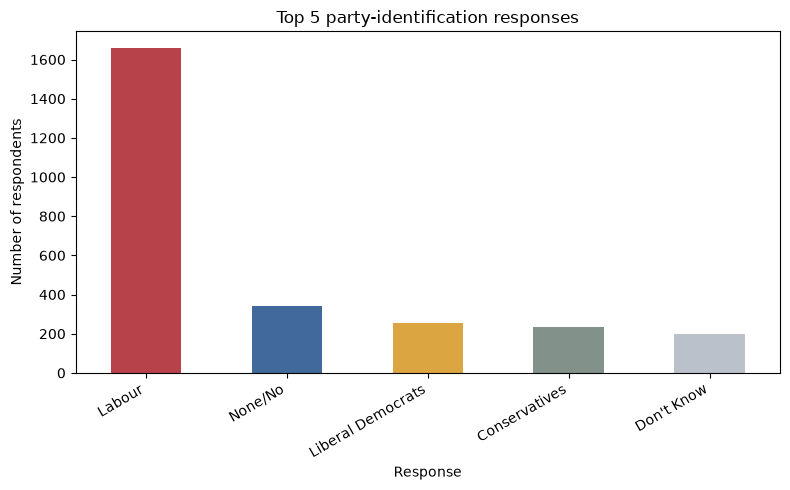

In [32]:
# BIG parties
df_study["Party_identification"].value_counts(dropna=False)

# making chart for the top 5 party-identification responses
top_5 = df_study["Party_identification"].value_counts().head(5)

colors = [
    "#b74249",
    "#41699b",
    "#dba642",
    "#82928b",
    "#bbc1cb",
]

top_5.plot.bar(figsize=(8, 5), color=colors)

plt.title("Top 5 party-identification responses")
plt.xlabel("Response")
plt.ylabel("Number of respondents")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Party,Labour,Conservative,Liberal Democrat,Other parties,None
Income_group,,,,,
"Up to £10,000",69.3,8.4,11.2,1.7,9.3
"£10,001–20,000",71.3,6.4,9.3,2.1,10.9
"£20,001–40,000",63.3,14.6,10.8,1.2,10.1
"Above £40,000",61.2,16.9,10.5,0.6,10.8


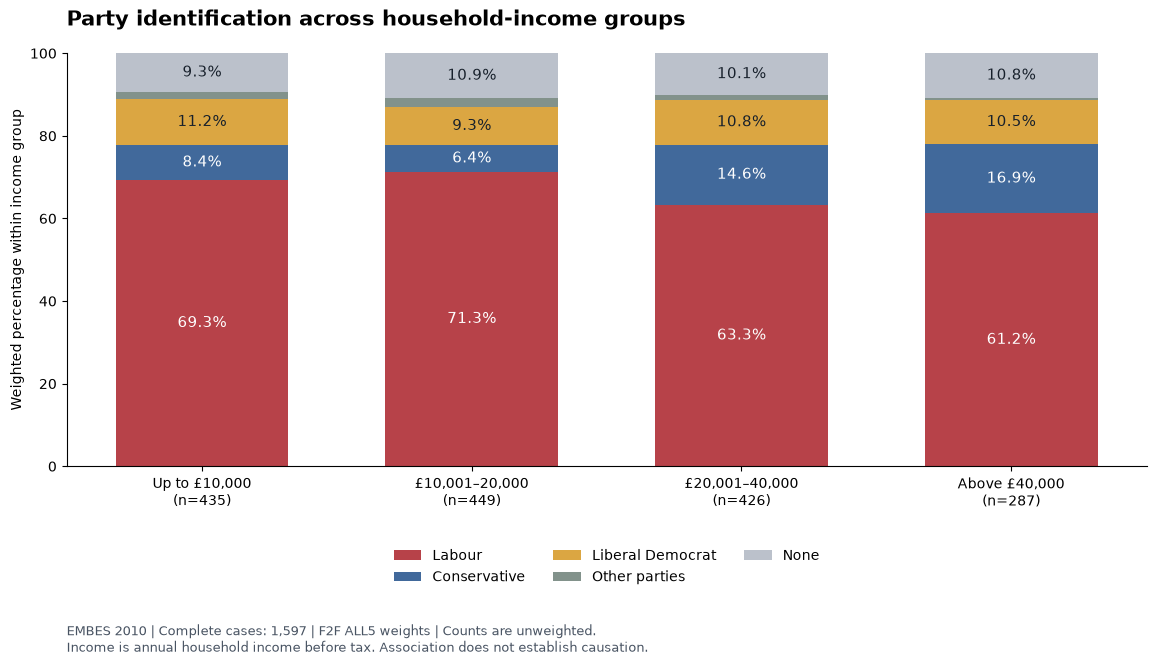

In [33]:
# Making vissualizations

# 1. Select the original numeric variables.
plot_data = df_main[
    ["zqinc", "bq9_1", "Weight_trimmedF2FALL5"]
].copy()

# 2. Keep valid income and party answers.
# Party code 1 (None/No) remains a valid response.
valid = (
    plot_data["zqinc"].between(1, 14)
    & plot_data["bq9_1"].between(1, 12)
)

plot_data = plot_data.loc[valid].copy()

# Check that all included respondents have valid survey weights.
weights = plot_data["Weight_trimmedF2FALL5"]
assert weights.notna().all() and (weights > 0).all()

# 3. Combine the 14 income bands into four groups.
income_labels = [
    "Up to £10,000",
    "£10,001–20,000",
    "£20,001–40,000",
    "Above £40,000",
]

plot_data["Income_group"] = pd.cut(
    plot_data["zqinc"],
    bins=[0, 2, 4, 8, 14],
    labels=income_labels,
)

# 4. Label parties and combine smaller parties.
party_labels = {
    1: "None",
    2: "Labour",
    3: "Conservative",
    4: "Liberal Democrat",
    5: "Other parties",
    6: "Other parties",
    7: "Other parties",
    8: "Other parties",
    9: "Other parties",
    10: "Other parties",
    11: "Other parties",
    12: "Other parties",
}

plot_data["Party"] = plot_data["bq9_1"].map(party_labels)

party_order = [
    "Labour",
    "Conservative",
    "Liberal Democrat",
    "Other parties",
    "None",
]

# 5. Sum survey weights for each income-party combination.
weighted_counts = (
    plot_data.groupby(
        ["Income_group", "Party"], observed=True
    )["Weight_trimmedF2FALL5"]
    .sum()
    .unstack(fill_value=0)
    .reindex(
        index=income_labels,
        columns=party_order,
        fill_value=0,
    )
)

# Convert to percentages WITHIN each income group.
percentages = weighted_counts.div(
    weighted_counts.sum(axis=1), axis=0
) * 100

# Actual respondent counts for the x-axis labels.
sample_sizes = (
    plot_data.groupby("Income_group", observed=True)
    .size()
    .reindex(income_labels, fill_value=0)
)

display(percentages.round(1))

# 6. Draw the stacked percentage chart.
colors = [
    "#b74249",
    "#41699b",
    "#dba642",
    "#82928b",
    "#bbc1cb",
]

fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(income_labels))
bottom = np.zeros(len(income_labels))

for party, color in zip(party_order, colors):
    values = percentages[party].to_numpy()

    ax.bar(
        x,
        values,
        bottom=bottom,
        width=0.64,
        label=party,
        color=color,
    )

    # Label larger segments to avoid overcrowding.
    for i, value in enumerate(values):
        if value >= 6:
            ax.text(
                x[i],
                bottom[i] + value / 2,
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontsize=11,
                color=(
                    "white"
                    if party in ["Labour", "Conservative"]
                    else "#17202b"
                ),
            )

    bottom += values

ax.set_xticks(
    x,
    [
        f"{label}\n(n={int(sample_sizes.loc[label])})"
        for label in income_labels
    ],
)

ax.set_ylim(0, 100)
ax.set_ylabel("Weighted percentage within income group")
ax.set_title(
    "Party identification across household-income groups",
    loc="left",
    fontweight="bold",
    fontsize=15,
    pad=20,
)

ax.spines[["top", "right"]].set_visible(False)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.17),
    ncol=3,
    frameon=False,
)

fig.text(
    0.08,
    0.025,
    f"EMBES 2010 | Complete cases: {len(plot_data):,} | "
    "F2F ALL5 weights | Counts are unweighted.\n"
    "Income is annual household income before tax. "
    "Association does not establish causation.",
    fontsize=9,
    color="#485362",
)

fig.subplots_adjust(
    left=0.08, right=0.98, top=0.88, bottom=0.29
)

# Optional: uncomment to save the chart.
# fig.savefig("income_party_chart.png", dpi=300, bbox_inches="tight")

plt.show()

In [34]:
# exploring the data 
df_main['ScreenEthQairre'].head(10)

0    4
1    1
2    4
3    4
4    4
5    4
6    4
7    4
8    1
9    2
Name: ScreenEthQairre, dtype: int8